In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.layers import *
from tensorflow.keras import models, Model
import qkeras
from qkeras import *

# two new layers
# 1) a input_reduce layer that cut off pixels at n_max_pixels with a feature threshold, output reduced map and a mask (1 for active, 0 for nonactive) (no threshold for this for hidden layers the output from previous layer can be standardized etc)
# 2) a mask_remove layer that remove nonactive pixels according to the mask from input_reduce, to be used after a normal qconv2d layer
# so sparse cnn: input -> input_reduce -> qconv2d -> mask_remove -> qactivation -> qpooling -> input_reduce (to generate updated mask) -> qconv2d -> mask_remove -> qactivation -> flatten -> ...

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

n_val = 10000
X_val = X_train[:n_val]
y_val = y_train[:n_val]
X_train = X_train[n_val:]
y_train = y_train[n_val:]

X_train = np.reshape(X_train, (-1,28,28,1)) / 255.
X_val = np.reshape(X_val, (-1,28,28,1)) / 255.
X_test = np.reshape(X_test, (-1,28,28,1)) / 255.

y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

print("X_train.shape: " + str(X_train.shape))
print("y_train.shape: " + str(y_train.shape))
print("X_val.shape: " + str(X_val.shape))
print("y_val.shape: " + str(y_val.shape))
print("X_test.shape: " + str(X_test.shape))
print("y_test.shape: " + str(y_test.shape))

X_train.shape: (50000, 28, 28, 1)
y_train.shape: (50000, 10)
X_val.shape: (10000, 28, 28, 1)
y_val.shape: (10000, 10)
X_test.shape: (10000, 28, 28, 1)
y_test.shape: (10000, 10)


In [27]:
def pool_and_pad_and_threshold(img, pool_size, pool_type, target_size=None, threshold=0):
    x = tf.convert_to_tensor(img, dtype=tf.float32)
    #x = tf.where(x<threshold, tf.zeros_like(x), x)

    k_h = k_w = pool_size

    if pool_type == 'max':
        pooled = tf.nn.max_pool2d(x, ksize=[1, k_h, k_w, 1], strides=[1, k_h, k_w, 1], padding='VALID')
    elif pool_type in ('avg'):
        pooled = tf.nn.avg_pool2d(x, ksize=[1, k_h, k_w, 1], strides=[1, k_h, k_w, 1], padding='VALID')

    old_h = tf.shape(x)[1]
    old_w = tf.shape(x)[2]
    new_h  = tf.shape(pooled)[1]
    new_w  = tf.shape(pooled)[2]

    if target_size is None:
        target_h, target_w = old_h, old_w
    else:
        target_h, target_w = target_size

    pad_y = target_h - new_h
    pad_x = target_w - new_w
    pad_top = pad_y // 2
    pad_bottom = pad_y - pad_top
    pad_left = pad_x // 2
    pad_right = pad_x - pad_left

    padded = tf.pad(
        pooled,
        [[0, 0], # batch
         [pad_top, pad_bottom], # h
         [pad_left, pad_right], # w
         [0, 0]], # c
        mode='CONSTANT',
        constant_values=0
    )

    max_per_img = tf.reduce_max(padded, axis=[1,2,3], keepdims=True)
    padded = tf.math.divide_no_nan(padded, max_per_img)
    padded = tf.where(padded<threshold, tf.zeros_like(padded), padded)

    return padded.numpy()

def plot_sparse(x_original, x_modified, n_example):
    img1 = x_original[n_example+1011]
    img2 = x_modified[n_example+1011]

    print('no. of active pixels (original): ' + str(np.count_nonzero(img1)) + ' / ' + str(img1.size) + ' = ' + str(np.count_nonzero(img1)/img1.size))
    print('no. of active pixels (modified): ' + str(np.count_nonzero(img2)) + ' / ' + str(img2.size) + ' = ' + str(np.count_nonzero(img2)/img2.size))

    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    axes[0].imshow(img1)
    axes[1].imshow(img2)
    plt.show()

no. of active pixels (original): 151 / 784 = 0.19260204081632654
no. of active pixels (modified): 16 / 1600 = 0.01


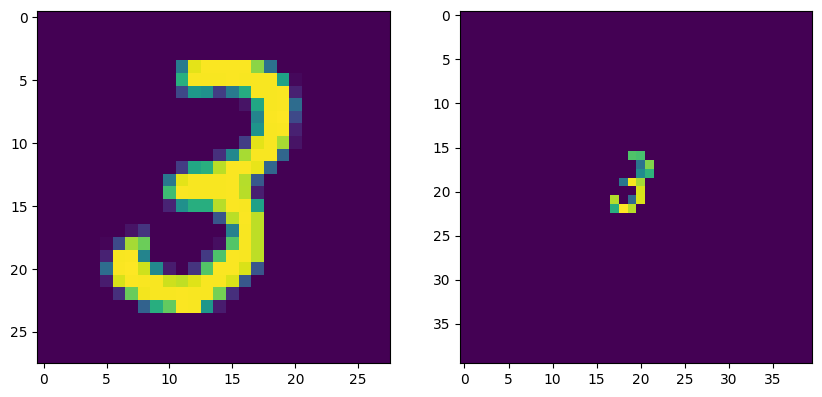

no. of active pixels (original): 129 / 784 = 0.16454081632653061
no. of active pixels (modified): 14 / 1600 = 0.00875


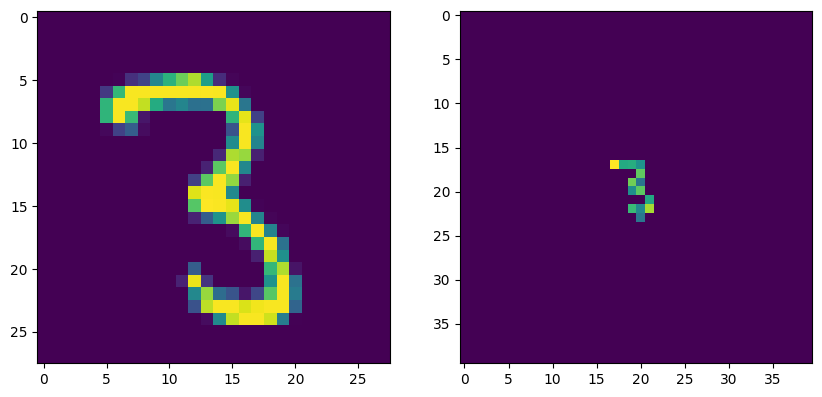

no. of active pixels (original): 197 / 784 = 0.2512755102040816
no. of active pixels (modified): 19 / 1600 = 0.011875


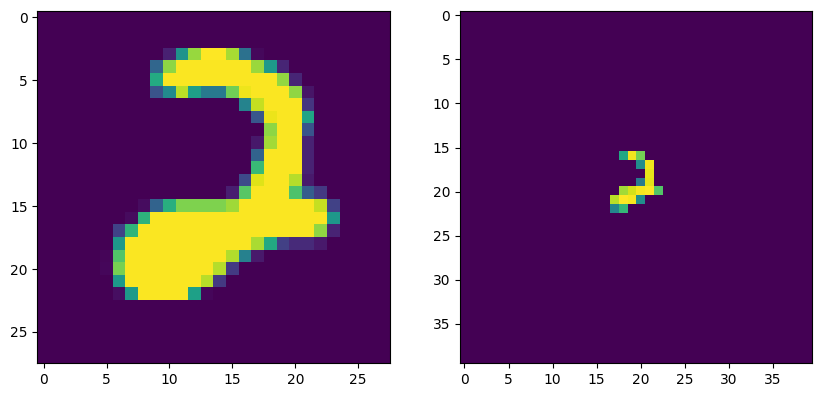

no. of active pixels (original): 177 / 784 = 0.22576530612244897
no. of active pixels (modified): 21 / 1600 = 0.013125


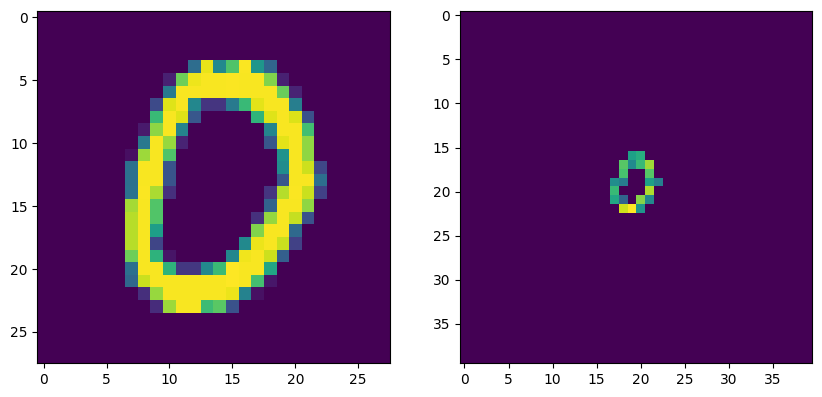

no. of active pixels (original): 162 / 784 = 0.2066326530612245
no. of active pixels (modified): 19 / 1600 = 0.011875


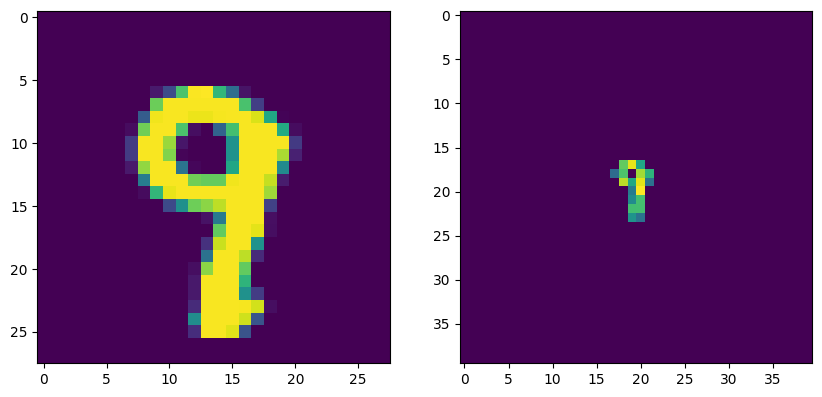

In [29]:
x_train = pool_and_pad_and_threshold(X_train, pool_size=3, pool_type='avg', target_size=(40,40), threshold=0.3)
x_val = pool_and_pad_and_threshold(X_val, pool_size=3, pool_type='avg', target_size=(40,40), threshold=0.3)
x_test = pool_and_pad_and_threshold(X_test, pool_size=3, pool_type='avg', target_size=(40,40), threshold=0.3)

for i in range(5):
    plot_sparse(X_train, x_train, i)

In [45]:
class InputReduce(tf.keras.layers.Layer):
    def __init__(self, n_max_pixels, threshold, **kwargs):
        super(InputReduce, self).__init__(**kwargs)
        self.n_max_pixels = n_max_pixels
        self.threshold = threshold

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        h = tf.shape(inputs)[1]
        w = tf.shape(inputs)[2]

        active_flag = tf.cast(inputs[..., 0] > self.threshold, tf.int32)
        active_flag_flat = tf.reshape(active_flag, [batch_size, h * w])
        active_count = tf.cumsum(active_flag_flat, axis=1)

        keep_mask_flat = tf.cast(tf.logical_and(active_flag_flat > 0, active_count <= self.n_max_pixels), inputs.dtype)
        keep_mask = tf.reshape(keep_mask_flat, [batch_size, h, w, 1])

        inputs_reduced = inputs * keep_mask
        return inputs_reduced, keep_mask

    def get_config(self):
        config = super(InputReduce, self).get_config()
        config.update({
            "n_max_pixels": self.n_max_pixels,
            "threshold": self.threshold
        })
        return config
    

class RemoveDilatedPixels(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(RemoveDilatedPixels, self).__init__(**kwargs)

    def call(self, inputs):
        x, mask = inputs
        mask = tf.cast(mask, x.dtype)
        removed = x * mask
        return removed

    def get_config(self):
        config = super(RemoveDilatedPixels, self).get_config()
        return config

In [46]:
for i, img in enumerate(x_train[:2]):
    print(f"Example {i}:")
    img2d = img[..., 0]
    for row in img2d:
        row_str = " ".join(
            "_____" if val == 0 
            else f"{val:.3f}"
            for val in row
        )
        print(row_str)
    print()

Example 0:
_____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____
_____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____
_____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____
_____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____
_____ _____ _____ _____ _____

In [53]:
xx, mask = InputReduce(n_max_pixels=10, threshold=0.3)(x_train[:2])
xxx = RemoveDilatedPixels()((xx, mask))
print(xx.shape, xxx.shape)

(2, 40, 40, 1) (2, 40, 40, 1)


In [56]:
for i, img in enumerate(xxx[:2]):
    print(f"Example {i}:")
    img2d = img[..., 0]
    for row in img2d:
        row_str = " ".join(
            "_____" if val == 0
            else f"{val:.3f}"
            for val in row
        )
        print(row_str)
    print()

Example 0:
_____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____
_____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____
_____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____
_____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____ _____
_____ _____ _____ _____ _____